# 03. Model Diagnostics & Governance
### Objective
This notebook performs a deep-dive validation of the LSTM Champion model. We assess its biological consistency and structural robustness to ensure it meets the high standards of a Reinsurance Risk Management framework.

### Actuarial Focus: Model Validation
Before a model can influence capital allocation, it must undergo "Diagnostic Testing". We use **Age-Period Residual Maps** to detect any systematic biases and perform an **Actuarial Stress Test** to visualize the impact of mortality shocks on survival curves.

## 3.1. Setup and Logging Silence

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings

# --- 1. Silence Warnings and System Logs ---
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

# --- 2. Load Data from Previous Notebooks ---
if not os.path.exists('../data/interim_params.pkl') or not os.path.exists('../data/champion_params.pkl'):
    raise FileNotFoundError("Run Notebook 01 and 02 first.")

with open('../data/interim_params.pkl', 'rb') as f:
    base_data = pickle.load(f)

with open('../data/champion_params.pkl', 'rb') as f:
    champ_data = pickle.load(f)

# Unpacking necessary variables
log_mx = base_data['log_mx']
alpha_x = base_data['alpha_x']
bx = base_data['bx']
kt = base_data['kt']

scaler_lstm = champ_data['scaler_lstm']
window_size = champ_data['window_size']

# Load the trained model
model = tf.keras.models.load_model('../models/lstm_champion.keras')

print("Environment ready. Model and parameters loaded successfully.")

Environment ready. Model and parameters loaded successfully.


## 3.2. Residual Heatmap (Structural Validation)

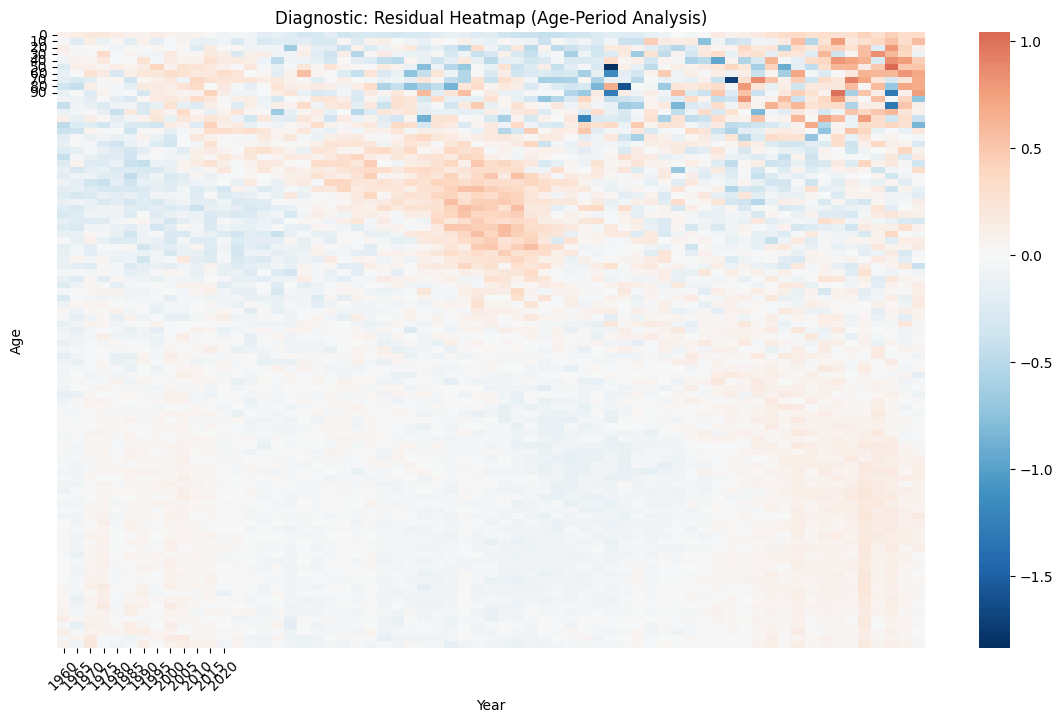

Residual analysis complete. Mean Residual: -0.003460


In [15]:
# --- 1. Reconstruct kt through the model ---
kt_scaled = scaler_lstm.transform(kt.reshape(-1, 1))
X_all = []
for i in range(len(kt_scaled) - window_size):
    X_all.append(kt_scaled[i:(i + window_size), 0])
X_all = np.array(X_all).reshape(-1, window_size, 1)

kt_rec_scaled = model.predict(X_all, verbose=0)
kt_rec = scaler_lstm.inverse_transform(kt_rec_scaled).flatten()

# --- 2. Robust Alignment and Residual Calculation ---
# Converting to numpy explicitly to avoid AttributeError
alpha_vec = alpha_x.values if hasattr(alpha_x, 'values') else alpha_x
bx_vec = bx.values if hasattr(bx, 'values') else bx

# Align actual data (skip the first 'window_size' years)
# Using .iloc if it's a DataFrame, otherwise standard slicing
actual_log_mx = log_mx.iloc[:, window_size:].values if hasattr(log_mx, 'iloc') else log_mx[:, window_size:]

# Predicted = alpha + (bx * kt_reconstructed)
pred_log_mx = alpha_vec[:, np.newaxis] + np.outer(bx_vec, kt_rec)

residuals = actual_log_mx - pred_log_mx

# --- 3. Plotting the Heatmap ---
plt.figure(figsize=(14, 8))
# xticklabels handling
years_labels = log_mx.columns[window_size:] if hasattr(log_mx, 'columns') else np.arange(len(kt_rec))
ages_labels = log_mx.index if hasattr(log_mx, 'index') else np.arange(len(alpha_vec))

sns.heatmap(residuals, cmap='RdBu_r', center=0, 
            xticklabels=years_labels[::5], 
            yticklabels=ages_labels[::10])

plt.title('Diagnostic: Residual Heatmap (Age-Period Analysis)')
plt.xlabel('Year'); plt.ylabel('Age')
plt.xticks(rotation=45)
plt.savefig('../reports/figures/05_residual_heatmap_diagnostic.png', dpi=300)
plt.show()

print(f"Residual analysis complete. Mean Residual: {np.mean(residuals):.6f}")

## 3.3. Actuarial Longevity Stress Test

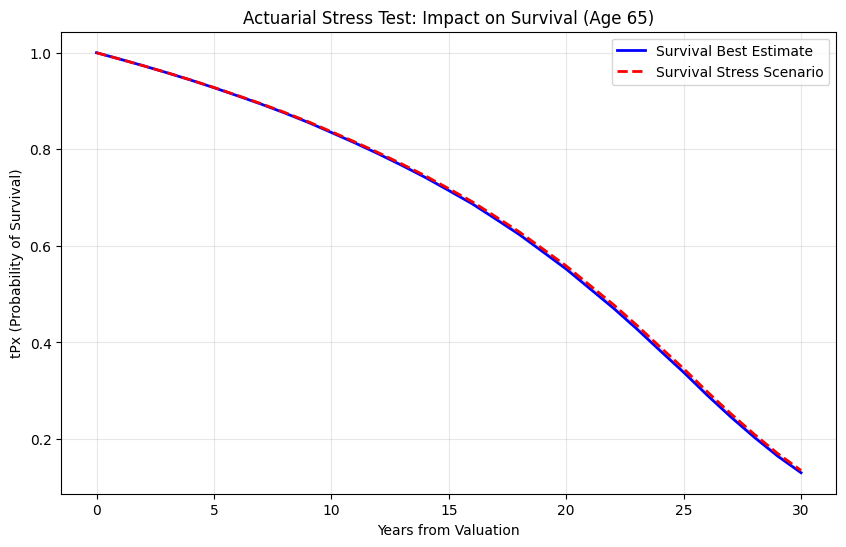

In [16]:
# --- 1. Scenario Definition ---
valuation_age = 65
time_horizon = 30 # Looking 30 years ahead

# Baseline (Best Estimate) vs Stress Scenario (Shocked kt)
kt_be = kt[-time_horizon:]
kt_stress = kt_be * 1.05 # Simple 5% shock for visualization purposes

# --- 2. Survival Probability (tPx) ---
def get_survival_curve(start_age, kt_trend, alpha, beta):
    mx_path = []
    for t, k_val in enumerate(kt_trend):
        age = min(start_age + t, 95)
        l_mx = alpha[age] + beta[age] * k_val
        mx_path.append(np.exp(l_mx))
    
    px = np.exp(-np.array(mx_path))
    return np.concatenate(([1.0], np.cumprod(px)))

surv_be = get_survival_curve(valuation_age, kt_be, alpha_x, bx)
surv_stress = get_survival_curve(valuation_age, kt_stress, alpha_x, bx)

# --- 3. Visualization ---
plt.figure(figsize=(10, 6))
plt.plot(surv_be, label='Survival Best Estimate', color='blue', linewidth=2)
plt.plot(surv_stress, 'r--', label='Survival Stress Scenario', linewidth=2)
plt.fill_between(range(len(surv_be)), surv_be, surv_stress, color='red', alpha=0.1)

plt.title(f'Actuarial Stress Test: Impact on Survival (Age {valuation_age})')
plt.xlabel('Years from Valuation'); plt.ylabel('tPx (Probability of Survival)')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('../reports/figures/06_actuarial_stress_test.png', dpi=300)
plt.show()